# KI und Algorithmen – Praxisnotebook

Dieses Notebook enthält:
1. Daten laden
2. Modell trainieren
3. Visualisierung und Auswertung
4. Übungen


In [27]:
# Funktionen definieren und libraries importieren
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Visualisierung der Entscheidungsgrenzen
import numpy as np
import matplotlib.pyplot as plt
def plot_decision_boundary(model, X, y):
    scaler = model.named_steps['standardscaler']
    knn = model.named_steps['kneighborsclassifier']
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    mesh_data = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns)
    Z = knn.predict(scaler.transform(mesh_data))
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor='k')
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(f'k={knn.n_neighbors} Entscheidungsgrenze')
    plt.show()

df = pd.read_csv('../Data/learning_style_classifier.csv')
X = df[['Lernzeit_h', 'Hausaufgabenquote']]
y = df['Bestanden']

k=1, Test accuracy=0.640


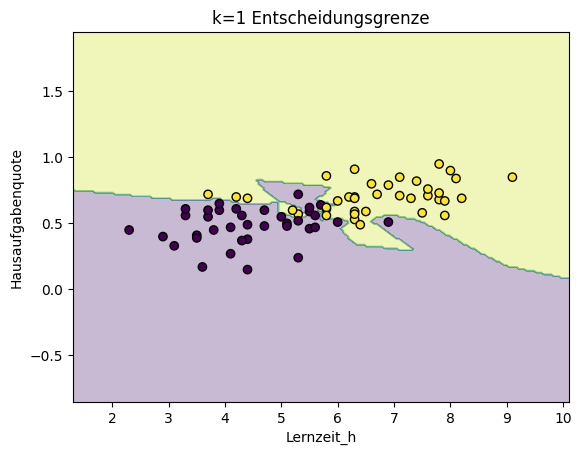

k=3, Test accuracy=0.720


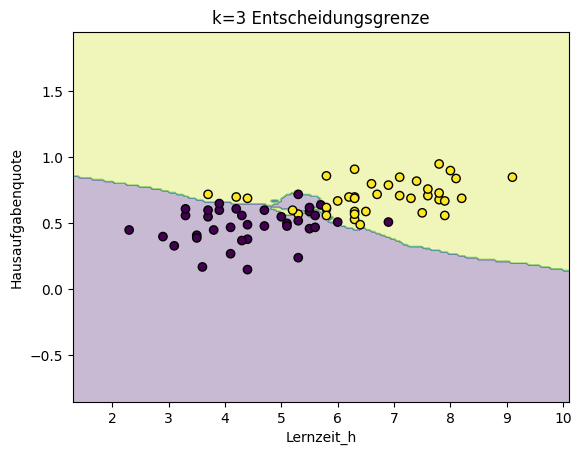

k=9, Test accuracy=0.880


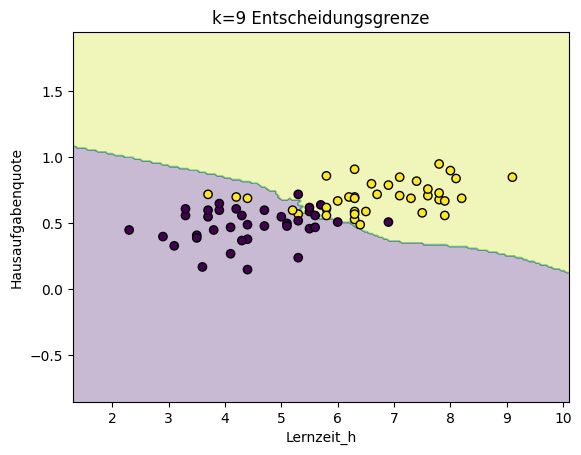

k=20, Test accuracy=0.840


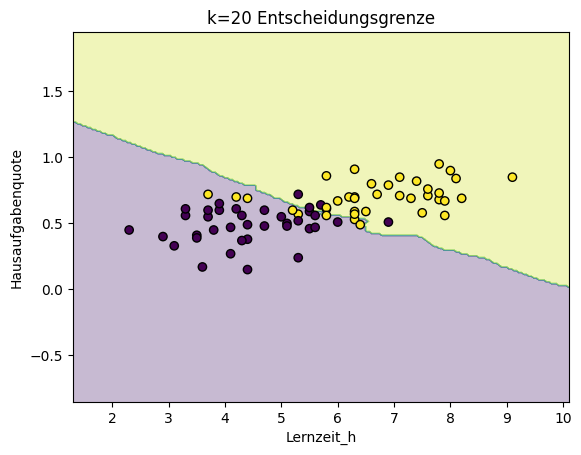

In [28]:
# Daten laden und vorbereiten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

for k in [1, 3, 9, 20]:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    print(f'k={k}, Test accuracy={acc:.3f}')
    plot_decision_boundary(knn, X_train, y_train)

## Übungen

Führen Sie eine erneute KNN-Klassifikation mit dem Datensatz `music_talent_classifier.csv`, mit folgenden Spaltennamen:

`Gehörtraining_Score,Rhythmusgefühl,Spielgeschwindigkeit_NPM,Musikalisches_Gedächtnis,Musikunterricht_Jahre,Talent_Niveau`.

Verwenden Sie die Spalten `Gehörtraining_Score` und `Rhythmusgefühl` als Features, und `Talent_Niveau` als Zielvariable. Trainieren Sie das Modell mit verschiedenen `k`-Werten (z.B. 1, 3, 9, 20) und beantworten Sie folgende Fragen:

1. Welches `k` liefert die beste Testgenauigkeit?
2. Warum kann `k=1` schnell zu Overfitting führen?
3. Wie verändert sich die Entscheidung bei sehr grossem `k`?


In [31]:
# Musik-Datensatz laden
df_music = pd.read_csv("../Data/music_talent_classifier.csv")

# Features und Ziel definieren
# TODO Ihr Code hier

# Train/Test-Split
# TODO Ihr Code hier

# Modelle mit verschiedenen k testen
# TODO Ihr Code hier